In [ ]:
!pip install pandas numpy matplotlib requests tqdm python-dateutil

In [ ]:
# scripts/fetch_weather_data.py
import os
import time
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from dateutil import tz
from tqdm import tqdm

# ------- CONFIG -------
INPUT_CSV = r"C:\Users\V14\Downloads\KAGGLEDATA-WEATHER.csv"
OUTPUT_CSV = r"C:\Users\V14\Downloads\weather_daily_by_city.csv"
DAYS_BACK = 30   # how many historical days to fetch
PAUSE_BETWEEN_CALLS = 1.0  # seconds - be polite
BASE_URL_ARCHIVE = "https://archive-api.open-meteo.com/v1/archive"
# DAILY PARAMETERS we want:
DAILY_VARS = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
]
TIMEZONE = "Asia/Manila"  # include timezone when requesting daily variables

# ------- Helper functions -------
def build_archive_url(lat, lon, start_date, end_date, daily_vars, timezone=TIMEZONE):
    daily = ",".join(daily_vars)
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": daily,
        "timezone": timezone
    }
    # Build URL with params (requests will encode)
    return BASE_URL_ARCHIVE, params

def safe_get(url, params, max_retries=3):
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            print(f"Request error (attempt {attempt+1}): {e}")
            time.sleep(2 + attempt*2)
    return None

# ------- Main -------
def main():
    os.makedirs("data", exist_ok=True)
    df_cities = pd.read_csv(INPUT_CSV)
    #for testing: only use the first city
    #df_cities = df_cities.head(1)
    end_date = datetime.now().date() - timedelta(days=1)
    start_date = end_date - timedelta(days=DAYS_BACK - 1)
    start_str = start_date.isoformat()
    end_str = end_date.isoformat()

    all_rows = []
    # Iterate cities
    for _, row in tqdm(df_cities.iterrows(), total=len(df_cities)):
        city = row.get("city_name", None)
        lat = row["latitude"]
        lon = row["longitude"]

        url, params = build_archive_url(lat, lon, start_str, end_str, DAILY_VARS)
        js = safe_get(url, params)
        if js is None:
            print(f"Failed to fetch for {city} ({lat},{lon})")
            continue

        # Parse dates & daily arrays
        dates = js.get("daily", {}).get("time", [])
        if not dates:
            print(f"No daily data for {city}")
            continue

        # For each daily var, pull arrays (some may be missing -> fill nan)
        data_cols = {}
        for var in DAILY_VARS:
            # mapping: API returns keys like 'temperature_2m_max' etc.
            data_cols[var] = js.get("daily", {}).get(var, [np.nan] * len(dates))

        # Build rows
        for i, dt in enumerate(dates):
            r = {
                "city_name": city,
                "latitude": lat,
                "longitude": lon,
                "date": dt
            }
            for var in DAILY_VARS:
                r[var] = data_cols[var][i] if i < len(data_cols[var]) else np.nan
            all_rows.append(r)

        # pause a bit to avoid spamming the API
        time.sleep(PAUSE_BETWEEN_CALLS)

    # Save combined DataFrame
    if all_rows:
        out_df = pd.DataFrame(all_rows)
        out_df.to_csv(OUTPUT_CSV, index=False)
        print("Saved:", OUTPUT_CSV)
    else:
        print("No data fetched.")

if __name__ == "__main__":
    main()


100%|██████████| 141/141 [04:54<00:00,  2.09s/it]

Saved: C:\Users\V14\Downloads\weather_daily_by_city.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv(r"C:\Users\V14\Downloads\weather_daily_by_city.csv", parse_dates=["date"])
df.head()

In [12]:
# basic checks
print("rows:", len(df))
print("date range:", df['date'].min(), "to", df['date'].max())
# convert to numeric (in case of missing strings)
numeric_cols = ['temperature_2m_max','temperature_2m_min','precipitation_sum','windspeed_10m_max']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

rows: 4230
date range: 2025-10-02 00:00:00 to 2025-10-31 00:00:00


In [13]:
agg = df.groupby("city_name")[numeric_cols].agg(['mean','max','min','std']).reset_index()
# Flatten MultiIndex columns
agg.columns = ['_'.join([a for a in col if a]) for col in agg.columns.to_flat_index()]
agg.sort_values('temperature_2m_max_mean', ascending=False).head(10)


,city_name,temperature_2m_max_mean,temperature_2m_max_max,temperature_2m_max_min,temperature_2m_max_std,temperature_2m_min_mean,temperature_2m_min_max,temperature_2m_min_min,temperature_2m_min_std,precipitation_sum_mean,precipitation_sum_max,precipitation_sum_min,precipitation_sum_std,windspeed_10m_max_mean,windspeed_10m_max_max,windspeed_10m_max_min,windspeed_10m_max_std
96,Panabo,32.616667,35.0,28.1,1.579848,24.123333,25.2,22.8,0.559361,7.836667,29.0,0.0,7.365038,12.380000,20.3,7.8,2.693978
68,Laoag,32.100000,34.3,28.6,1.429251,23.843333,26.0,21.6,1.071796,3.656667,23.5,0.0,5.669013,12.240000,32.4,6.5,5.045216
47,Digos,31.840000,34.0,27.2,1.627691,24.590000,26.0,23.5,0.650914,3.790000,17.5,0.0,5.145695,12.753333,25.1,6.2,4.197350
85,Mati,31.713333,34.3,27.3,1.498213,24.910000,26.1,23.9,0.688001,3.453333,13.4,0.2,3.851442,13.533333,20.5,6.5,3.223441
53,General Santos,31.683333,34.2,27.7,1.750878,24.556667,25.9,23.6,0.554408,4.866667,15.2,0.0,4.276668,12.233333,19.8,5.0,3.128659
18,Butuan,31.543333,34.9,27.9,1.611100,24.016667,25.0,23.4,0.398344,6.153333,30.1,0.2,6.129563,12.903333,18.5,7.6,2.638244
55,Gingoog City,31.293333,34.3,29.2,1.307520,23.696667,24.4,21.7,0.629441,6.700000,15.3,0.0,4.776306,9.180000,12.7,5.5,2.100640
93,Ozamiz City,31.190000,35.1,26.7,1.576410,24.033333,25.3,23.2,0.526755,7.536667,44.1,0.0,9.421819,13.516667,21.9,6.6,4.165216
9,Batac City,31.176667,33.1,28.0,1.243932,23.940000,25.9,20.6,1.050648,4.370000,19.9,0.0,5.493705,13.370000,30.2,7.2,4.682922
131,Urdaneta,31.173333,33.4,26.3,1.377637,23.686667,25.5,22.5,0.646867,10.070000,92.4,0.0,18.010651,13.373333,30.2,6.6,5.174135


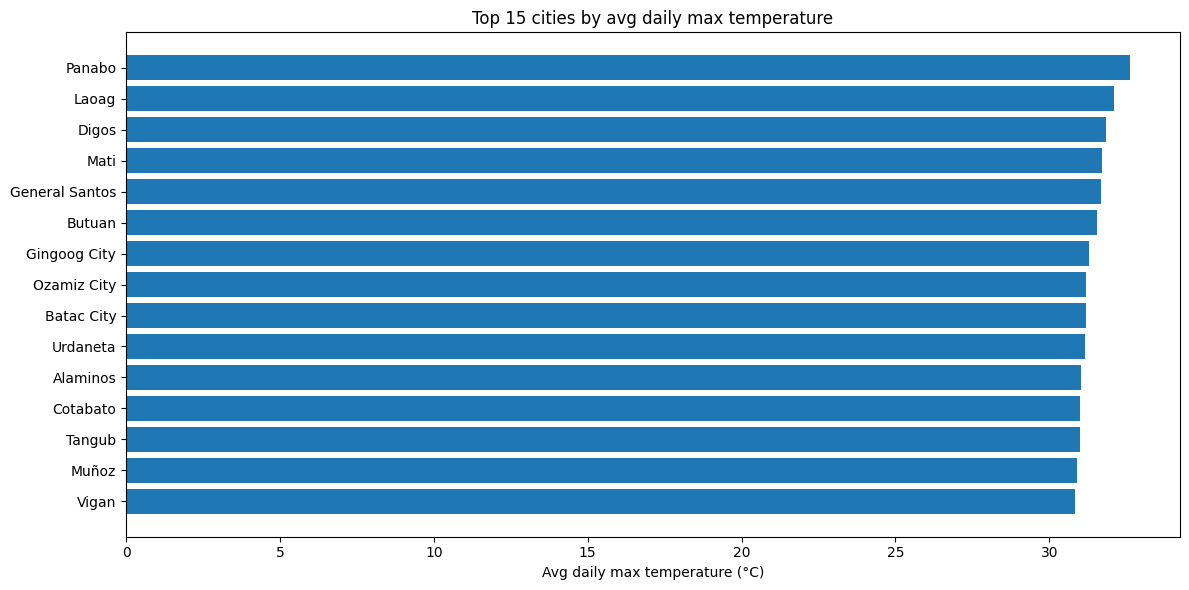

In [15]:
topn = 15
top = agg.sort_values('temperature_2m_max_mean', ascending=False).head(topn)
plt.figure(figsize=(12,6))
plt.barh(top['city_name'], top['temperature_2m_max_mean'])
plt.gca().invert_yaxis()
plt.xlabel("Avg daily max temperature (°C)")
plt.title(f"Top {topn} cities by avg daily max temperature")
plt.tight_layout()
plt.show()

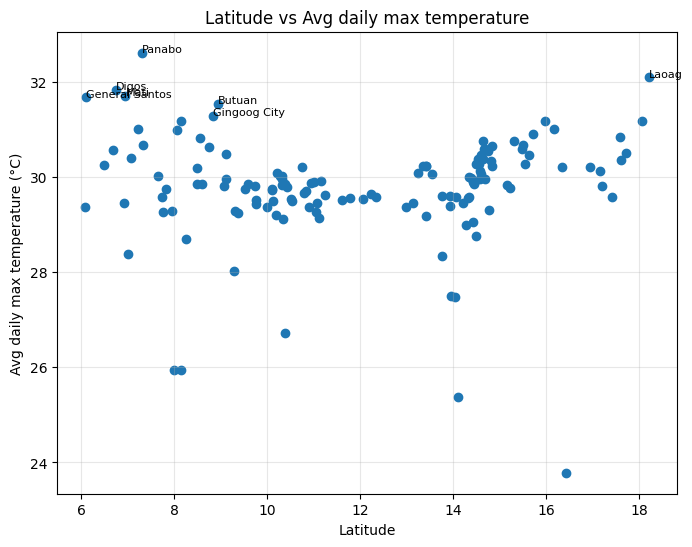

In [16]:
# need mapping of latitude -> city average temp
lat_map = df.groupby('city_name')[['latitude']].first()
temp_mean = df.groupby('city_name')['temperature_2m_max'].mean().rename("avg_temp_max")
scatter = lat_map.join(temp_mean).dropna()

plt.figure(figsize=(8,6))
plt.scatter(scatter['latitude'], scatter['avg_temp_max'])
plt.xlabel("Latitude")
plt.ylabel("Avg daily max temperature (°C)")
plt.title("Latitude vs Avg daily max temperature")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(alpha=0.3)
for i,row in scatter.iterrows():
    if row['avg_temp_max'] > scatter['avg_temp_max'].quantile(0.95):  # label extreme points
        plt.text(row['latitude'], row['avg_temp_max'], i, fontsize=8)
plt.show()

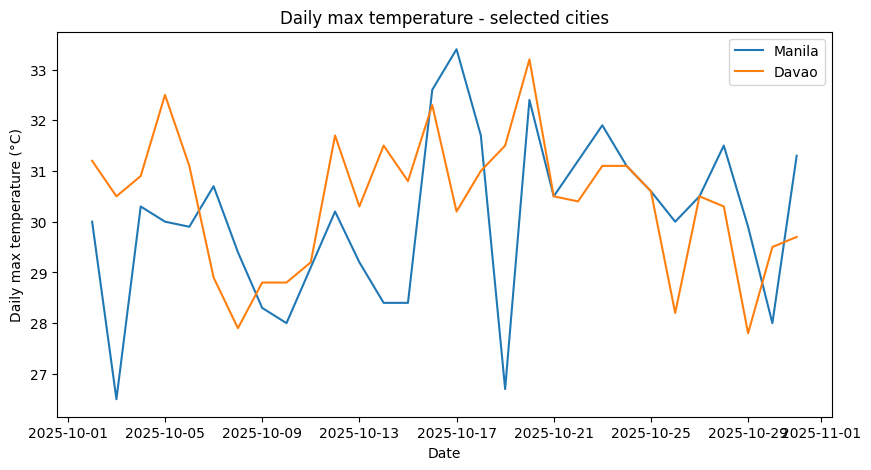

In [17]:
selected = ['Manila', 'Cebu', 'Davao'] 
for city in selected:
    s = df[df['city_name']==city].sort_values('date')
    if s.empty:
        continue
    plt.plot(s['date'], s['temperature_2m_max'], label=city)
plt.legend()
plt.xlabel("Date")
plt.ylabel("Daily max temperature (°C)")
plt.title("Daily max temperature - selected cities")
plt.show()

# Weather Data Insights (Open-Meteo)

This project enriches a city coordinates list with real historical weather data using the Open-Meteo API,
then produces basic analyses and visualizations using Pandas, NumPy, and Matplotlib.

## Structure
- `data/`
  - `KAGGLEDATA-WEATHER.csv`  (city_name, latitude, longitude)
  - `weather_daily_by_city.csv` (generated by the script)
- `scripts/`
  - `fetch_weather_data.py`
- `notebooks/`
  - `Weather_Insights.ipynb`
- `README.md`

## How to run
1. Create a Python environment and install requirements:
2. Update `scripts/fetch_weather_data.py` if needed (date range, pause).
3. Run:
This will produce `data/weather_daily_by_city.csv`.
4. Open `notebooks/Weather_Insights.ipynb` and run the cells to generate plots.

## Notes
- This project uses Open-Meteo (free, no API key) for historical and forecast data. Daily variables require the
`timezone` parameter. See https://open-meteo.com for details.


